In [2]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alfiyahazzahra","key":"1b63241d0c6118f889c741bd1553585d"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list -s "ecommerce"

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saurabhshahane/ecommerce-text-classification                    Ecommerce Text Classification                         8236809  2023-10-09 14:01:29.687000          15679        110                1  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18284        212        0.7058824  
mmohaiminulislam/ecommerce-data-analysis                        ECommerce Data Analysis                              17628279  2024-01-01 02:04:35.787000           9900         69                1  
aadit

In [5]:
!kaggle datasets download -d uzmaakhtar/ecommerce-sales-data

Dataset URL: https://www.kaggle.com/datasets/uzmaakhtar/ecommerce-sales-data
License(s): apache-2.0
100% 41.4k/41.4k [00:00<00:00, 46.5MB/s]



In [6]:
!unzip ecommerce-sales-data.zip

Archive:  ecommerce-sales-data.zip
  inflating: ecommerce_sales_data.csv  


In [7]:
import os
os.listdir()

['.config',
 'ecommerce-sales-data.zip',
 'ecommerce_sales_data.csv',
 'kaggle.json',
 'sample_data']

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ecommerce_sales_data.csv')
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [9]:
df.info()
df.isnull().sum()
df.columns = ['order_date','product_name','category','region','quantity','sales','profit']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


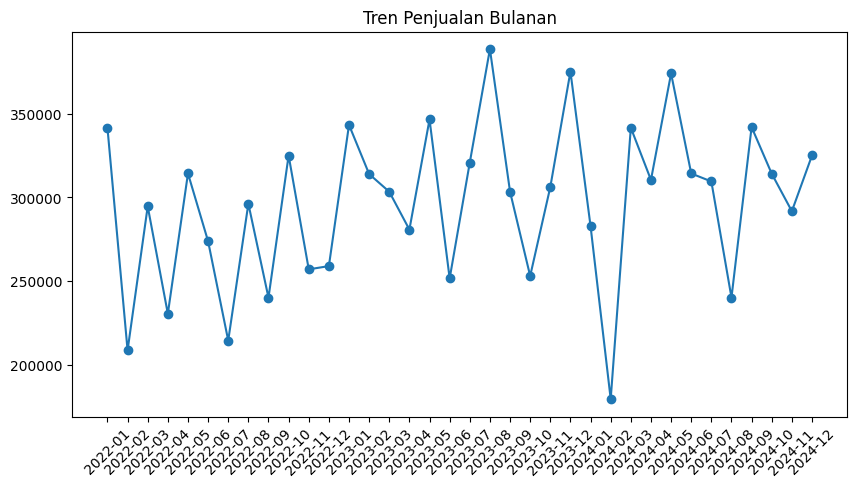

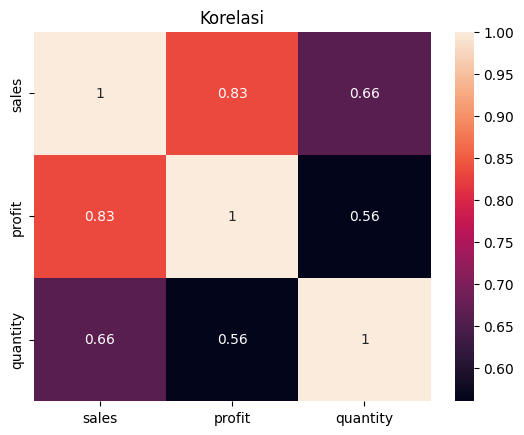

In [10]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('month')['sales'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=45)
plt.title('Tren Penjualan Bulanan')
plt.show()
import seaborn as sns

correlation = df[['sales','profit','quantity']].corr()

sns.heatmap(correlation, annot=True)
plt.title('Korelasi')
plt.show()


**TUGAS PRAKTIKUM**

In [11]:
df['price_per_unit'] = df['sales'] / df['quantity']
df.head()

,order_date,product_name,category,region,quantity,sales,profit,month,price_per_unit
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024-12,910.0
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022-11,171.0
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022-05,1173.0
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024-03,393.0
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022-09,509.0


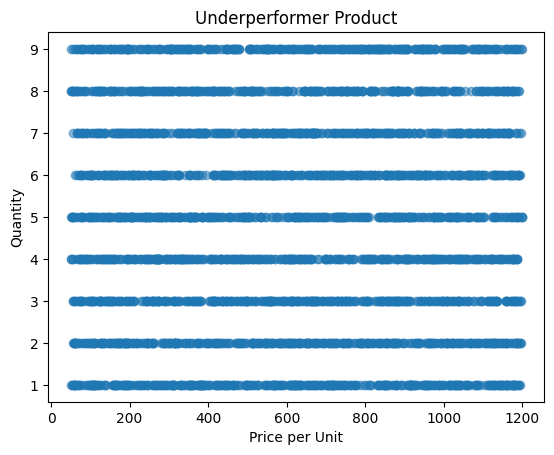

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df['price_per_unit'], df['quantity'], alpha=0.5)
plt.xlabel('Price per Unit')
plt.ylabel('Quantity')
plt.title('Underperformer Product')
plt.show()

In [13]:
avg_price = df['price_per_unit'].mean()

underperformer = df[df['price_per_unit'] > avg_price]

underperformer.groupby('product_name')['quantity'].sum().sort_values().head()

,quantity
product_name,
Smartwatch,762
Headphones,767
Tablet,801
Laptop,812
Keyboard,818




> **Berdasarkan hasil analisis, ditemukan bahwa beberapa produk memiliki harga per unit yang tinggi namun jumlah penjualan yang rendah. Hal ini menunjukkan bahwa harga yang terlalu tinggi dapat menjadi faktor penghambat dalam meningkatkan volume penjualan. Oleh karena itu, produk-produk tersebut dapat dikategorikan sebagai underperformer dan perlu dilakukan evaluasi strategi harga.**



In [17]:
import datetime as dt

snapshot_date = df['order_date'].max() + dt.timedelta(days=1)

rfm = df.groupby('product_name').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'quantity': 'sum',
    'sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
product_name,,,
Camera,2,1795,1177381
Headphones,2,1604,988638
Keyboard,5,1684,1024507
Laptop,3,1658,1005873
Monitor,3,1876,1160048




> **Produk dengan nilai Recency rendah (baru saja dibeli), Frequency tinggi, dan Monetary tinggi merupakan produk dengan performa terbaik dan layak diprioritaskan dalam strategi pemasaran.**



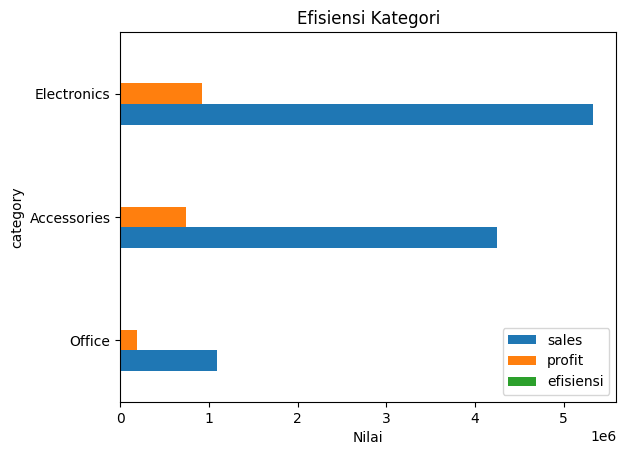

In [18]:
kategori = df.groupby('category').agg({
    'sales':'sum',
    'profit':'sum'
})

kategori['efisiensi'] = kategori['profit'] / kategori['sales']

kategori = kategori.sort_values('efisiensi')

import matplotlib.pyplot as plt

kategori.plot(kind='barh')
plt.title('Efisiensi Kategori')
plt.xlabel('Nilai')
plt.show()



> **Kategori dengan rasio profit terhadap sales yang rendah menunjukkan efisiensi yang kurang baik, sehingga perlu dilakukan evaluasi strategi harga atau biaya**.



**UJI HIPOTESIS SEDERHANA**


> **Analisis ini bertujuan untuk menguji apakah peningkatan anggaran iklan (Ad_Budget) berpengaruh terhadap peningkatan penjualan (Total_Sales). Namun, pada dataset yang saya gunakan ini tidak tersedia variabel terkait dengan anggaran iklan, sehingga pengujian hipotesis ini tidak dapat dilakukan**.



In [19]:
import datetime as dt

snapshot_date = df['order_date'].max() + dt.timedelta(days=1)

rfm = df.groupby('product_name').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'quantity': 'sum',
    'sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

# Skoring
import pandas as pd

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
product_name,,,,,,,
Camera,2,1795,1177381,4,4,5,445
Headphones,2,1604,988638,4,1,1,411
Keyboard,5,1684,1024507,1,2,2,122
Laptop,3,1658,1005873,3,2,1,321
Monitor,3,1876,1160048,3,5,5,355




> **Produk dengan skor RFM tinggi menunjukkan performa terbaik karena sering dibeli, menghasilkan penjualan tinggi, dan baru saja dibeli. Produk ini harus diprioritaskan dalam strategi pemasaran.**



In [20]:
from sklearn.linear_model import LinearRegression

X = df[['quantity']]
y = df['sales']

model = LinearRegression()
model.fit(X, y)

print(model.coef_)
print(model.intercept_)

[627.57310922]
-47.0452680578328




> **Persamaan regresi linear sederhana digunakan untuk mengetahui hubungan antara variabel independen (x) dan variabel dependen (y). Dalam konteks ini, variabel x adalah Biaya Iklan (Ad_Budget) dan variabel y adalah Total Penjualan (Total_Sales). Nilai β₀ (intercept) menunjukkan besarnya penjualan ketika tidak ada biaya iklan, sedangkan β₁ (koefisien) menunjukkan seberapa besar peningkatan penjualan untuk setiap kenaikan satu satuan biaya iklan. Sementara itu, ε (error) merepresentasikan faktor lain di luar model yang dapat mempengaruhi penjualan. Namun, pada dataset yang saya gunakan dalam praktikum ini tidak tersedia variabel Biaya Iklan (Ad_Budget), sehingga analisis regresi linear tidak dapat diterapkan secara langsung. Oleh karena itu, model ini hanya dijelaskan secara teoritis tanpa implementasi pada data yang tersedia.**



***STRUKTUR LAPORAN PRAKTIKUM :***
1. **Business Question**


> Produk apa saja yang termasuk underperformer (harga tinggi namun penjualan rendah)?

> Produk mana yang memiliki performa terbaik berdasarkan analisis RFM?

> Kategori produk mana yang paling efisien dalam menghasilkan profit?



2. **Data Wrangling**

> Dataset berisi 3500 data transaksi tanpa missing value.
Dilakukan pengecekan tipe data menggunakan df.info() dan tidak ditemukan nilai kosong. Nama kolom disederhanakan agar mudah digunakan dalam analisis. Kolom order_date diubah ke format datetime untuk mempermudah analisis waktu. Dibuat kolom baru price_per_unit untuk menghitung harga per produk.

3. **Insights**

*- Underperformer Product :*

> Berdasarkan analisis, ditemukan beberapa produk dengan harga per unit tinggi namun memiliki jumlah penjualan rendah. Hal ini menunjukkan bahwa harga yang terlalu tinggi dapat menjadi faktor penghambat dalam meningkatkan volume penjualan.

*- Visualisasi Scatter Plot :*

> Scatter plot menunjukkan bahwa produk dengan harga tinggi cenderung memiliki jumlah penjualan yang lebih rendah, yang mengindikasikan adanya hubungan negatif antara harga dan jumlah pembelian.

*- RFM Analysis (Adaptasi) :*

> Produk dengan nilai Recency rendah (baru dibeli), Frequency tinggi, dan Monetary tinggi merupakan produk dengan performa terbaik dan layak diprioritaskan dalam strategi pemasaran.

*- Efisiensi Kategori :*

> Kategori dengan rasio profit terhadap sales yang rendah menunjukkan efisiensi yang kurang baik, sehingga perlu dilakukan evaluasi strategi harga atau biaya.

*- Keterbatasan Data :*

> Dataset tidak menyediakan data pelanggan dan anggaran iklan, sehingga beberapa analisis seperti RFM berbasis pelanggan dan uji pengaruh iklan tidak dapat dilakukan secara optimal.

4. Recommendation:

> Evaluasi harga pada produk yang memiliki harga tinggi namun penjualan rendah.
Fokus pada produk dengan performa tinggi untuk meningkatkan profit.
Optimalkan kategori dengan efisiensi rendah melalui strategi pemasaran atau pengurangan biaya.
Tambahkan data seperti pelanggan dan anggaran iklan untuk analisis yang lebih mendalam di masa depan.

5. Catatan :

> Analisis regresi linear tidak dapat dilakukan karena tidak tersedia variabel Biaya Iklan (Ad_Budget) dalam dataset, sehingga model hanya dijelaskan secara teoritis.